In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import matplotlib.gridspec as gridspec

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

### Residuals Comparison

In [3]:
exop_folder = '../exop_hosts/'
age_pred = pd.read_csv(exop_folder + 'exop_host_ages-v1/age_predictions.csv')
archive_ages = pd.read_csv(exop_folder + 'archive_ages_default.csv')

In [4]:
age_pred['pred_median_myr'] = 10**age_pred['pred_median']
age_pred['pred_p16_myr'] = 10**age_pred['pred_p16']
age_pred['pred_p84_myr'] = 10**age_pred['pred_p84']
age_pred['1sigma'] = (age_pred['pred_p84'] - age_pred['pred_p16']) / 2
age_pred['1sigma_upper'] = age_pred['pred_p84'] - age_pred['pred_median']
age_pred['1sigma_lower'] = age_pred['pred_median'] - age_pred['pred_p16']
age_pred['1sigma_upper_myr'] = age_pred['pred_p84_myr'] - age_pred['pred_median_myr']
age_pred['1sigma_lower_myr'] = age_pred['pred_median_myr'] - age_pred['pred_p16_myr']
age_pred['1sigma_myr'] = (age_pred['1sigma_upper_myr'] + age_pred['1sigma_lower_myr']) / 2

In [18]:
archive_ages['logA_Myr'] = np.log10(archive_ages['st_age'] * 1e3)
archive_ages['logA_Myr_err'] = (np.log10(archive_ages['st_age'] + archive_ages['st_ageerr1']) - np.log10((archive_ages['st_age'] + archive_ages['st_ageerr2']).clip(lower=0.00001)))/2
archive_ages['st_err'] = (archive_ages['st_ageerr1'] + archive_ages['st_ageerr2']) / 2

# Filter out stars that are 1 Myr or younger
archive_ages = archive_ages[archive_ages['logA_Myr'] > 0]


In [19]:
def combine_group(g):
    mean_logA = g['logA_Myr'].mean()
    mean_ageGyr = g['st_age'].mean()
    mean_err_sq = (g['logA_Myr_err'] ** 2).mean()
    mean_err_ageGyr_sq = (g['st_err'] ** 2).mean()
    spread_sq = g['logA_Myr'].std(ddof=0) ** 2  # ddof=0: population std since we want the scatter, not SE
    combined_err = np.sqrt(mean_err_sq + spread_sq)
    return pd.Series({
        'logA_Myr': mean_logA,
        'logA_Myr_err': combined_err,
        'st_age': mean_ageGyr,
        'st_err': np.sqrt(mean_err_ageGyr_sq + (g['st_age'].std(ddof=0) ** 2)),
        'n_estimates': len(g),
    })

archive_ages_grouped = (
    archive_ages
    .groupby('GaiaDR3_ID', as_index=True)
    .apply(combine_group)
    .reset_index()
)


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_91678/3518911051.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(combine_group)


In [20]:
joined = age_pred.merge(archive_ages_grouped, left_on='gaia_id', right_on='GaiaDR3_ID', how='inner')

### Age prediction histogram

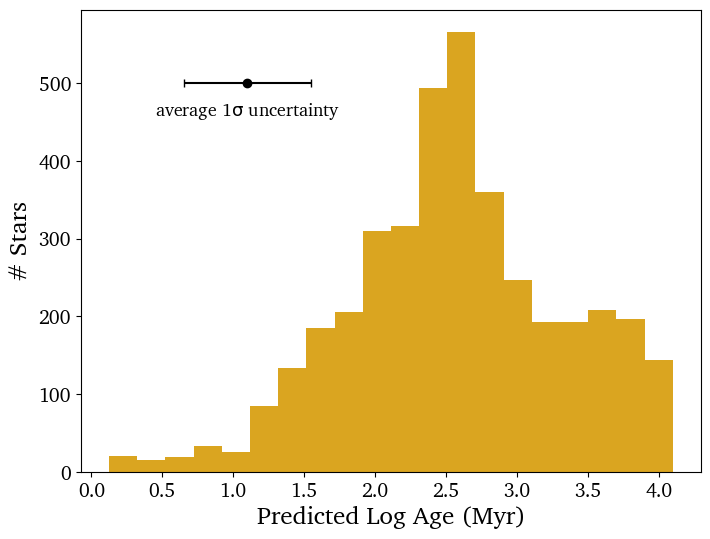

In [9]:
fig = plt.figure(figsize=(8,6))
plt.hist(age_pred['pred_median'], bins=20, alpha=1, label='Median estimate',color='goldenrod')
# plt.hist(age_pred['pred_map'], bins=20, alpha=0.5, label='MAP Estimate')
plt.errorbar(1.1,500,xerr=np.mean(age_pred['1sigma']), fmt='o', color='black', label='Average 1-sigma uncertainty',capsize=3)
plt.text(1.1, 450, r'average 1$\rm \sigma$ uncertainty', ha='center', va='bottom',fontsize=13)
plt.xlabel('Predicted Log Age (Myr)',fontsize=18)
plt.ylabel('# Stars',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend()
plt.show()

### Comparison of lit age estimates

In [10]:
med_xerr = np.mean(joined['logA_Myr_err'])
med_yerr = np.mean(joined['1sigma'])

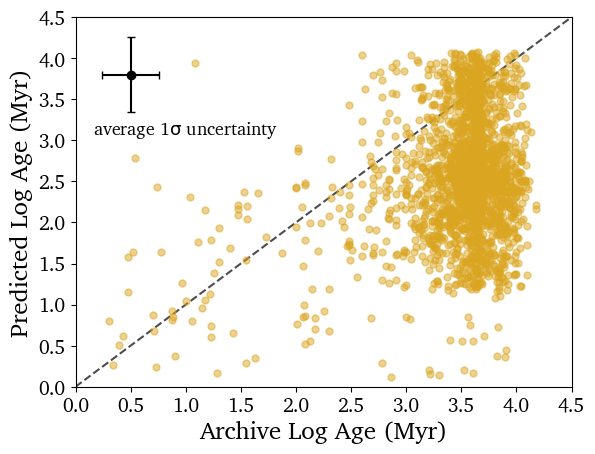

In [21]:
plt.errorbar(joined['logA_Myr'], joined['pred_median'],
             xerr=joined['logA_Myr_err'], yerr=[joined['1sigma_lower'], joined['1sigma_upper']], fmt='o', alpha=0.5,
             markersize=5,elinewidth=0, capsize=0,color='goldenrod')
plt.errorbar(0.5,3.8, xerr=med_xerr, yerr=med_yerr, fmt='o', color='black', label='Average 1-sigma uncertainty',capsize=3)
plt.text(1, 3, r'average 1$\rm \sigma$ uncertainty', ha='center', va='bottom',fontsize=13)
plt.xlabel('Archive Log Age (Myr)',fontsize=18)
plt.ylabel('Predicted Log Age (Myr)',fontsize=18)
plt.plot([0,5], [0,5], 'k--', alpha=0.7)
plt.xlim(0,4.5)
plt.ylim(0,4.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

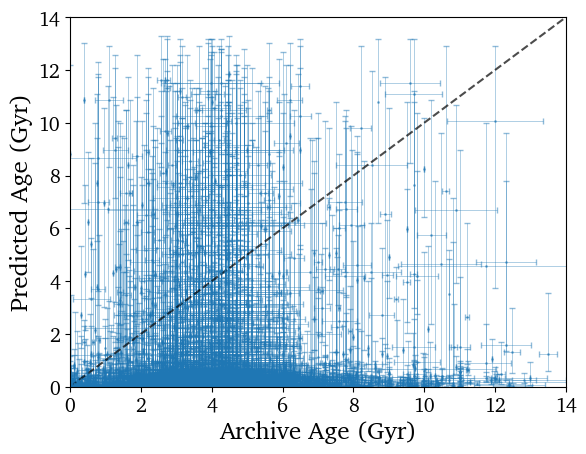

In [119]:
plt.errorbar(joined['st_age'], joined['pred_median_myr']/1000, xerr=joined['st_err'],
             yerr=[joined['1sigma_lower_myr']/1000, joined['1sigma_upper_myr']/1000], fmt='o', alpha=0.5,
             markersize=1,elinewidth=0.5, capsize=2)
plt.xlabel('Archive Age (Gyr)',fontsize=18)
plt.ylabel('Predicted Age (Gyr)',fontsize=18)
plt.plot([0,14], [0,14], 'k--', alpha=0.7)
plt.xlim(0,14)
plt.ylim(0,14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

### Filtering by minimum level of uncertainty

In [ ]:
joined['frac_logA_Myr_err'] = joined['logA_Myr_err'] / joined['logA_Myr']
joined['frac_1sigma'] = joined['1sigma'] / joined['pred_median']


#### Plot of uncertainties

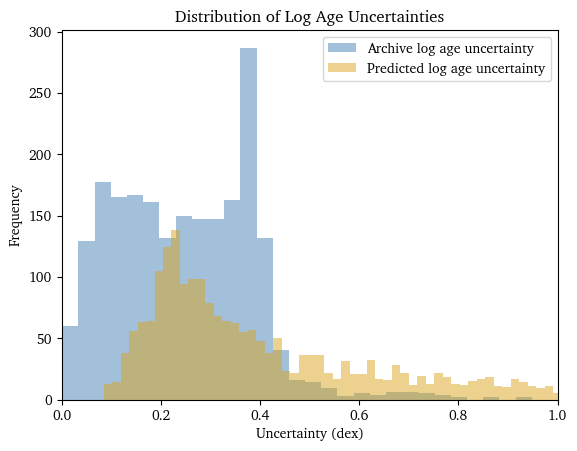

In [30]:
plt.hist(joined['logA_Myr_err'], bins=100, alpha=0.5, label='Archive log age uncertainty',color='steelblue')
plt.hist(joined['1sigma'], bins=100, alpha=0.5, label='Predicted log age uncertainty',color='goldenrod')
plt.xlim(0,1)
plt.xlabel('Uncertainty (dex)')
plt.ylabel('Frequency')
plt.title('Distribution of Log Age Uncertainties')
plt.legend()
plt.show()

#### Plot of fractional uncertainties

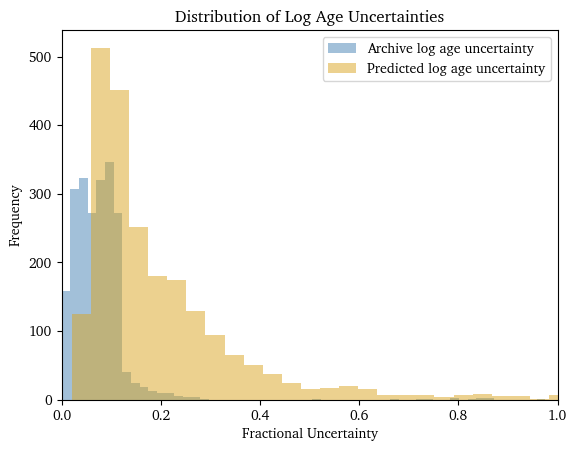

In [ ]:
plt.hist(joined['frac_logA_Myr_err'], bins=100, alpha=0.5, label='Archive log age uncertainty',color='steelblue')
plt.hist(joined['frac_1sigma'], bins=100, alpha=0.5, label='Predicted log age uncertainty',color='goldenrod')
plt.xlim(0,1)
plt.xlabel('Fractional Uncertainty')
plt.ylabel('Frequency')
plt.title('Distribution of Log Age Uncertainties')
plt.legend()
plt.show()

### Filtering by low error

In [31]:
joined_acc = joined[(joined['logA_Myr_err'] <= 0.5) & (joined['1sigma'] <= 0.5)]


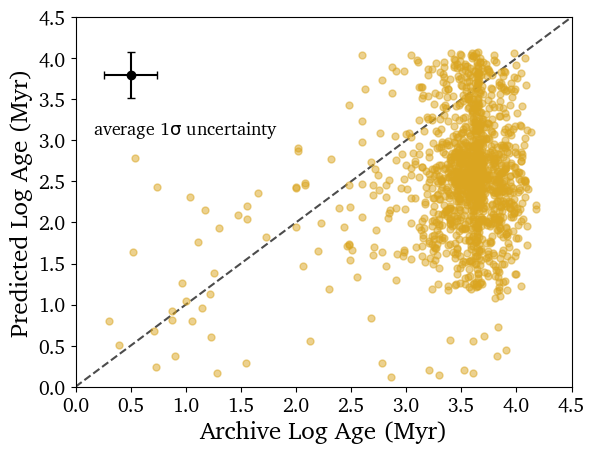

In [33]:
med_xerr = np.mean(joined_acc['logA_Myr_err'])
med_yerr = np.mean(joined_acc['1sigma'])
plt.errorbar(joined_acc['logA_Myr'], joined_acc['pred_median'],
             xerr=joined_acc['logA_Myr_err'], yerr=[joined_acc['1sigma_lower'], joined_acc['1sigma_upper']], fmt='o', alpha=0.5,
             markersize=5,elinewidth=0, capsize=0,color='goldenrod')
plt.errorbar(0.5,3.8, xerr=med_xerr, yerr=med_yerr, fmt='o', color='black', label='Average 1-sigma uncertainty',capsize=3)
plt.text(1, 3, r'average 1$\rm \sigma$ uncertainty', ha='center', va='bottom',fontsize=13)
plt.xlabel('Archive Log Age (Myr)',fontsize=18)
plt.ylabel('Predicted Log Age (Myr)',fontsize=18)
plt.plot([0,5], [0,5], 'k--', alpha=0.7)
plt.xlim(0,4.5)
plt.ylim(0,4.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()